In [1]:
import os

dataset_path = "Chili Growth Stage Original Dataset"

print("Dataset folder exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Inside dataset folder:")
    print(os.listdir(dataset_path))

Dataset folder exists: True
Inside dataset folder:
['Chili Growth Stage Original Dataset']


In [3]:
import os

dataset_path = "Chili Growth Stage Original Dataset"

classes = [
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili",
    "Dry Chili"
]

total = 0

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.exists(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{class_name}: {len(images)} images")
        total += len(images)
    else:
        print(f"{class_name}: Folder not found")

print("\nTotal images:", total)

Flower: Folder not found
Green Chili: Folder not found
Red Chili: Folder not found
Rotten Chili: Folder not found
Dry Chili: Folder not found

Total images: 0


In [4]:
import os

dataset_path = "Chili Growth Stage Original Dataset"

print("Main folder contents:")
for item in os.listdir(dataset_path):
    print(item)

Main folder contents:
Chili Growth Stage Original Dataset


In [5]:
import os

dataset_path = os.path.join(
    "Chili Growth Stage Original Dataset",
    "Chili Growth Stage Original Dataset"
)

print("Dataset path exists:", os.path.exists(dataset_path))

print("\nInside actual dataset folder:")
for item in os.listdir(dataset_path):
    print(item)

Dataset path exists: True

Inside actual dataset folder:
Dry chili
Flower
Green Chili
Red Chili
Rotten Chili


In [6]:
import os

dataset_path = os.path.join(
    "Chili Growth Stage Original Dataset",
    "Chili Growth Stage Original Dataset"
)

classes = [
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili",
    "Dry chili"
]

total = 0

print("IMAGE COUNT BY CLASS")
print("-" * 30)

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}: {len(images)} images")
    total += len(images)

print("-" * 30)
print(f"Total images: {total}")

IMAGE COUNT BY CLASS
------------------------------
Flower: 397 images
Green Chili: 328 images
Red Chili: 200 images
Rotten Chili: 379 images
Dry chili: 410 images
------------------------------
Total images: 1714


In [7]:
from PIL import Image
import os

corrupted_images = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, file_name)

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception as e:
                corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for image in corrupted_images:
        print(image)
else:
    print("All images are readable.")

Corrupted images: 0
All images are readable.


In [8]:
import os
import hashlib
from collections import defaultdict

hash_to_files = defaultdict(list)

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, file_name)

            with open(image_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_to_files[file_hash].append(
                (class_name, file_name)
            )

duplicate_groups = {
    h: files
    for h, files in hash_to_files.items()
    if len(files) > 1
}

print("Total images checked:", sum(len(v) for v in hash_to_files.values()))
print("Unique images:", len(hash_to_files))
print("Duplicate groups:", len(duplicate_groups))

if duplicate_groups:
    print("\nDuplicate files:")
    for files in duplicate_groups.values():
        print(files)
else:
    print("\nNo exact duplicate images found.")

Total images checked: 1714
Unique images: 1714
Duplicate groups: 0

No exact duplicate images found.


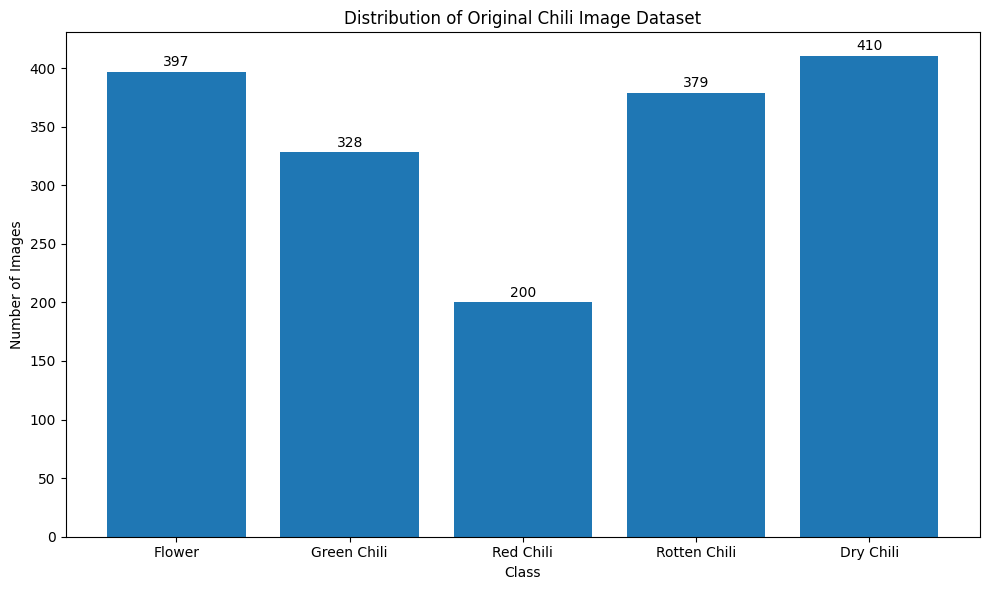

In [1]:
import matplotlib.pyplot as plt

class_counts = {
    "Flower": 397,
    "Green Chili": 328,
    "Red Chili": 200,
    "Rotten Chili": 379,
    "Dry Chili": 410
}

plt.figure(figsize=(10, 6))

bars = plt.bar(class_counts.keys(), class_counts.values())

plt.title("Distribution of Original Chili Image Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        str(height),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [4]:
import os
import random
import shutil

# Reproducible split
random.seed(42)

# Output folder
split_path = "dataset_split"

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Create train, validation and test folders
for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_path, split, class_name),
            exist_ok=True
        )

print("Split folders created successfully.")

Split folders created successfully.


In [3]:
import os

dataset_path = os.path.join(
    "Chili Growth Stage Original Dataset",
    "Chili Growth Stage Original Dataset"
)

classes = [
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili",
    "Dry chili"
]

print("Dataset ready:", os.path.exists(dataset_path))
print("Classes:", classes)

Dataset ready: True
Classes: ['Flower', 'Green Chili', 'Red Chili', 'Rotten Chili', 'Dry chili']


In [11]:
import os
import random
import shutil

random.seed(42)

for class_name in classes:
    source_folder = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Randomize images
    random.shuffle(images)

    total_images = len(images)

    train_end = int(total_images * 0.70)
    val_end = train_end + int(total_images * 0.15)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    split_groups = {
        "train": train_images,
        "validation": val_images,
        "test": test_images
    }

    for split_name, file_list in split_groups.items():
        destination_folder = os.path.join(
            split_path,
            split_name,
            class_name
        )

        for file_name in file_list:
            source_file = os.path.join(source_folder, file_name)
            destination_file = os.path.join(
                destination_folder,
                file_name
            )

            shutil.copy2(source_file, destination_file)

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

print("\nDataset split completed successfully.")

OSError: [WinError 112] There is not enough space on the disk

In [1]:
import os

dataset_path = os.path.join(
    "Chili Growth Stage Original Dataset",
    "Chili Growth Stage Original Dataset"
)

classes = [
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili",
    "Dry chili"
]

print("Current working folder:", os.getcwd())
print("Dataset ready:", os.path.exists(dataset_path))
print("Classes:", classes)

Current working folder: D:\Chili_Project
Dataset ready: True
Classes: ['Flower', 'Green Chili', 'Red Chili', 'Rotten Chili', 'Dry chili']


In [2]:
import os
import random
import shutil

random.seed(42)

split_path = "dataset_split"

# Create folders
for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_path, split, class_name),
            exist_ok=True
        )

# Split each class
for class_name in classes:

    source_folder = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total_images = len(images)

    train_end = int(total_images * 0.70)
    val_end = train_end + int(total_images * 0.15)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    split_groups = {
        "train": train_images,
        "validation": val_images,
        "test": test_images
    }

    for split_name, file_list in split_groups.items():

        destination_folder = os.path.join(
            split_path,
            split_name,
            class_name
        )

        for file_name in file_list:

            source_file = os.path.join(
                source_folder,
                file_name
            )

            destination_file = os.path.join(
                destination_folder,
                file_name
            )

            shutil.copy2(
                source_file,
                destination_file
            )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

print("\nDataset split completed successfully.")

Flower: Train=277, Validation=59, Test=61
Green Chili: Train=229, Validation=49, Test=50
Red Chili: Train=140, Validation=30, Test=30
Rotten Chili: Train=265, Validation=56, Test=58
Dry chili: Train=287, Validation=61, Test=62

Dataset split completed successfully.


In [3]:
import os
import hashlib

def get_image_hashes(folder):
    hashes = set()
    count = 0

    for class_name in classes:
        class_folder = os.path.join(folder, class_name)

        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

                file_path = os.path.join(class_folder, file_name)

                with open(file_path, "rb") as f:
                    image_hash = hashlib.md5(f.read()).hexdigest()

                hashes.add(image_hash)
                count += 1

    return hashes, count


train_hashes, train_count = get_image_hashes(
    os.path.join(split_path, "train")
)

val_hashes, val_count = get_image_hashes(
    os.path.join(split_path, "validation")
)

test_hashes, test_count = get_image_hashes(
    os.path.join(split_path, "test")
)

print("Train images:", train_count)
print("Validation images:", val_count)
print("Test images:", test_count)
print("Total images:", train_count + val_count + test_count)

print("\nOVERLAP CHECK")
print("-" * 30)

print(
    "Train vs Validation:",
    len(train_hashes.intersection(val_hashes))
)

print(
    "Train vs Test:",
    len(train_hashes.intersection(test_hashes))
)

print(
    "Validation vs Test:",
    len(val_hashes.intersection(test_hashes))
)

Train images: 1198
Validation images: 255
Test images: 261
Total images: 1714

OVERLAP CHECK
------------------------------
Train vs Validation: 0
Train vs Test: 0
Validation vs Test: 0


In [4]:
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    print("TensorFlow is ready!")
except ImportError:
    print("TensorFlow is NOT installed.")

TensorFlow is NOT installed.


In [1]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow version:", tf.__version__)
print("TensorFlow ready:", True)

Python: 3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]
TensorFlow version: 2.21.0
TensorFlow ready: True


In [2]:
import os
import tensorflow as tf

dataset_path = os.path.join(
    "Chili Growth Stage Original Dataset",
    "Chili Growth Stage Original Dataset"
)

split_path = "dataset_split"

classes = [
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili",
    "Dry chili"
]

train_dir = os.path.join(split_path, "train")
val_dir = os.path.join(split_path, "validation")
test_dir = os.path.join(split_path, "test")

print("Train folder:", os.path.exists(train_dir))
print("Validation folder:", os.path.exists(val_dir))
print("Test folder:", os.path.exists(test_dir))
print("Number of classes:", len(classes))

Train folder: True
Validation folder: True
Test folder: True
Number of classes: 5


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nDetected classes:", class_names)
print("Number of classes:", len(class_names))

Found 1198 files belonging to 5 classes.
Found 255 files belonging to 5 classes.
Found 261 files belonging to 5 classes.

Detected classes: ['Dry chili', 'Flower', 'Green Chili', 'Red Chili', 'Rotten Chili']
Number of classes: 5


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            f"{class_names[labels[i]]}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Matplotlib ready!")
print("Environment ready!")

Matplotlib is building the font cache; this may take a moment.


TensorFlow version: 2.21.0
Matplotlib ready!
Environment ready!


In [2]:
import os
import tensorflow as tf

# Dataset locations
split_path = "dataset_split"

train_dir = os.path.join(split_path, "train")
val_dir = os.path.join(split_path, "validation")
test_dir = os.path.join(split_path, "test")

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClass order:")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

Found 1198 files belonging to 5 classes.
Found 255 files belonging to 5 classes.
Found 261 files belonging to 5 classes.

Class order:
0 -> Dry chili
1 -> Flower
2 -> Green Chili
3 -> Red Chili
4 -> Rotten Chili


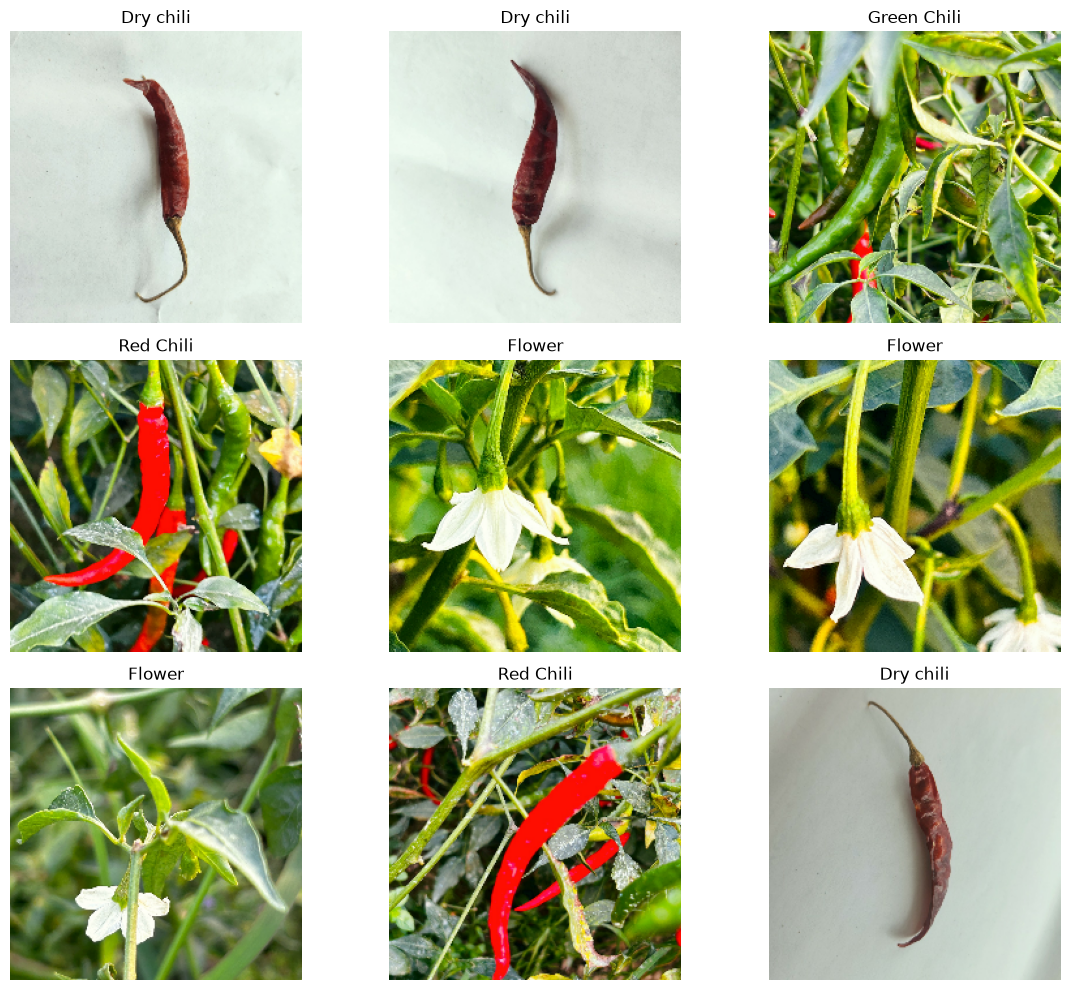

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation pipeline created successfully!")

Data augmentation pipeline created successfully!


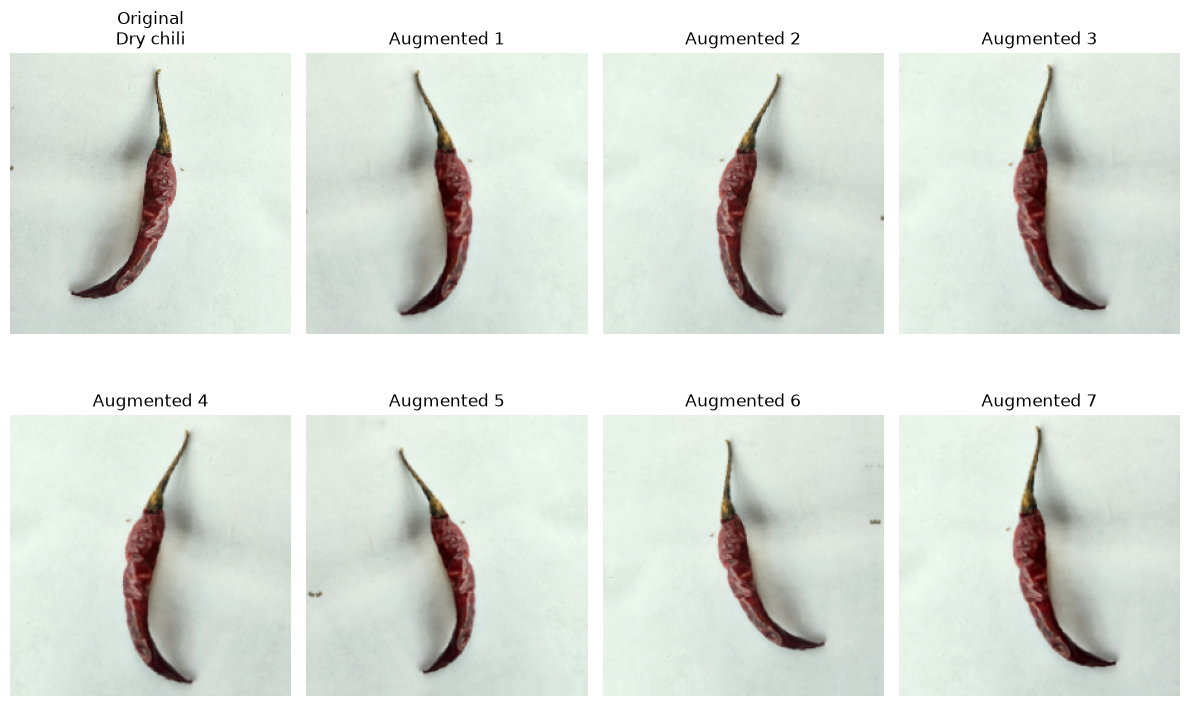

In [5]:
import matplotlib.pyplot as plt

# Take one image from the training dataset
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]

    plt.figure(figsize=(12, 8))

    # Original image
    ax = plt.subplot(2, 4, 1)
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(
        "Original\n" +
        class_names[sample_label.numpy()]
    )
    plt.axis("off")

    # Generate 7 augmented versions
    for i in range(7):
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        ax = plt.subplot(2, 4, i + 2)
        plt.imshow(
            tf.cast(augmented_image[0], tf.uint8).numpy()
        )
        plt.title(f"Augmented {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers for the first training stage
base_model.trainable = False

# Build classification model
inputs = tf.keras.Input(shape=(224, 224, 3))

# Training-only augmentation
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing
x = preprocess_input(x)

# Pretrained feature extractor
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(
    inputs,
    outputs,
    name="Chili_Maturity_MobileNetV2"
)

print("MobileNetV2 model created successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 158s 17us/step
MobileNetV2 model created successfully!


In [7]:
model.summary()

Model: "Chili_Maturity_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [9]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath="best_mobilenetv2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized successfully!")

Dataset pipeline optimized successfully!


In [11]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

D:\Chili_Project\chili_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7012 - loss: 0.7834
Epoch 1: val_accuracy improved from None to 0.87843, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.7012 - loss: 0.7834 - val_accuracy: 0.8784 - val_loss: 0.2995 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9224 - loss: 0.2507
Epoch 2: val_accuracy improved from 0.87843 to 0.92157, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9224 - loss: 0.2507 - val_accuracy: 0.9216 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9416 - loss: 0.1763
Epoch 3: val_accuracy improved from 0.92157 to 0.96471, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mobilenetv2.keras
38/38 ━━━━━━━━━━

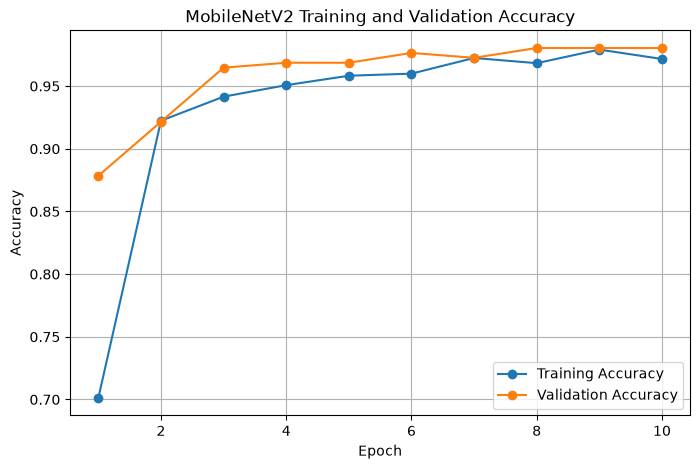

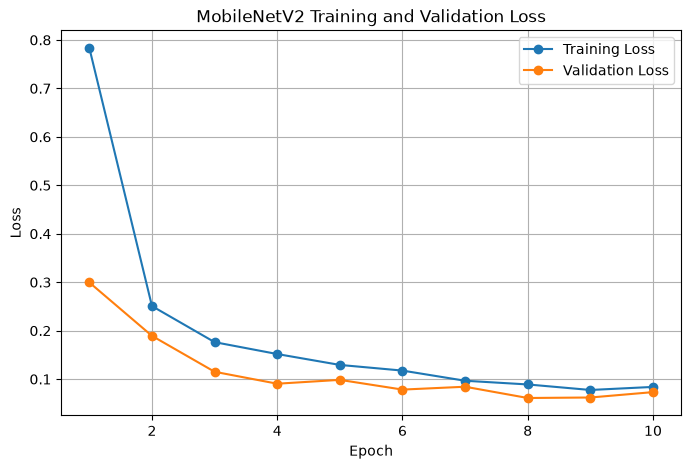

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history.history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINAL TEST RESULTS")
print("----------------------------")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9693 - loss: 0.0740

FINAL TEST RESULTS
----------------------------
Test Accuracy: 96.93%
Test Loss: 0.0740


In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluation libraries ready!")

ModuleNotFoundError: No module named 'sklearn'

In [16]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn
import tensorflow as tf
import numpy as np

print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("Ready!")

Scikit-learn: 1.9.1
TensorFlow: 2.21.0
Ready!


In [3]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Test dataset location
test_dir = os.path.join("dataset_split", "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Reload untouched test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names

# Reload best saved model
model = tf.keras.models.load_model(
    "best_mobilenetv2.keras"
)

print("\nBest model loaded successfully!")
print("Classes:", class_names)
print("Test images:", sum(1 for _ in test_ds.unbatch()))

Found 261 files belonging to 5 classes.

Best model loaded successfully!
Classes: ['Dry chili', 'Flower', 'Green Chili', 'Red Chili', 'Rotten Chili']
Test images: 261


In [4]:
# Collect true labels
y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

# Predict all test images
y_prob = model.predict(
    test_ds,
    verbose=1
)

# Convert probabilities to predicted class numbers
y_pred = np.argmax(y_prob, axis=1)

print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Dry chili     1.0000    1.0000    1.0000        62
      Flower     0.9839    1.0000    0.9919        61
 Green Chili     1.0000    0.9600    0.9796        50
   Red Chili     0.9615    0.8333    0.8929        30
Rotten Chili     0.9048    0.9828    0.9421        58

    accuracy                         0.9693       261
   macro avg     0.9700    0.9552    0.9613       261
weighted avg     0.9706    0.9693    0.9690       261



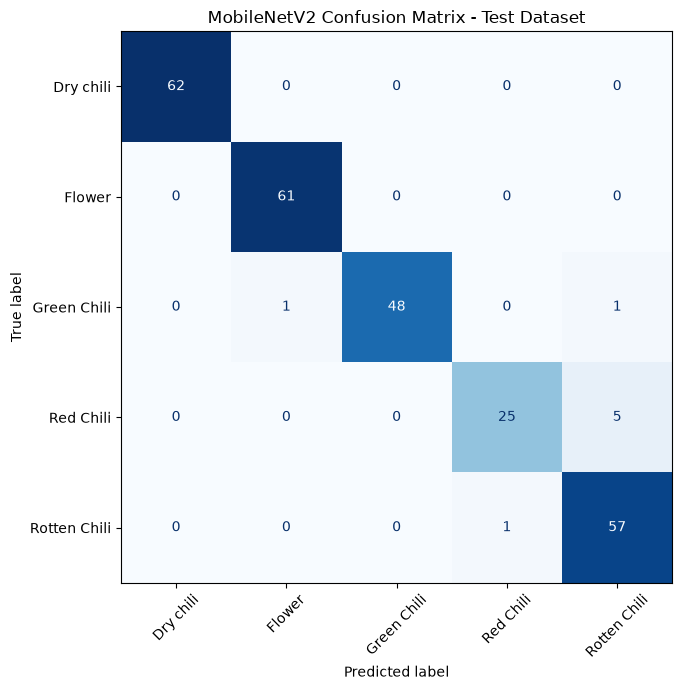

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("MobileNetV2 Confusion Matrix - Test Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total misclassified images: 8


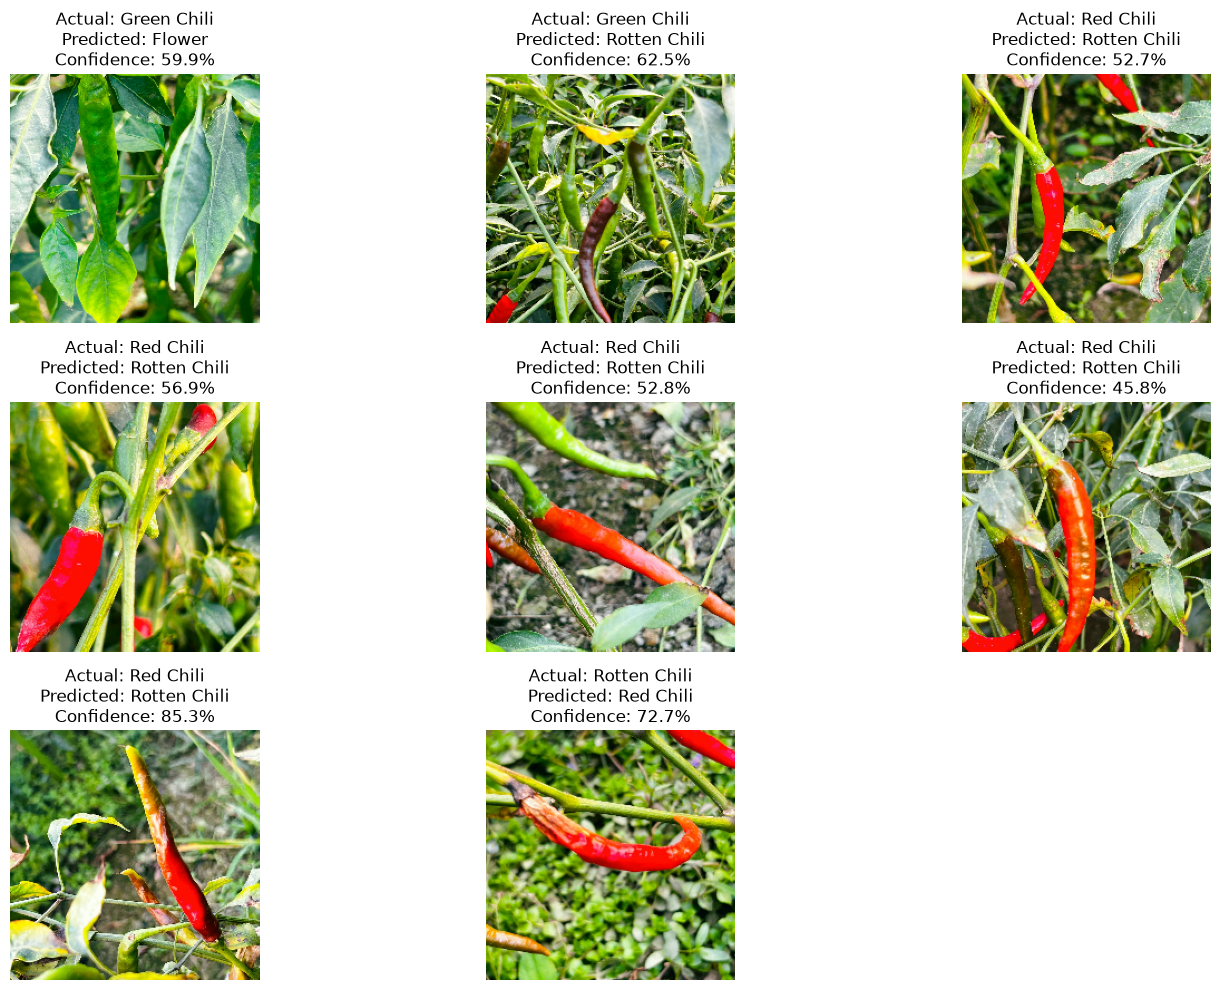

In [6]:
# Collect test images
all_images = np.concatenate([
    images.numpy() for images, labels in test_ds
])

# Find incorrect predictions
wrong_indices = np.where(y_true != y_pred)[0]

print("Total misclassified images:", len(wrong_indices))

plt.figure(figsize=(15, 10))

for i, idx in enumerate(wrong_indices):
    plt.subplot(3, 3, i + 1)

    plt.imshow(all_images[idx].astype("uint8"))

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = np.max(y_prob[idx]) * 100

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Unfreeze the MobileNetV2 base model
base_model = model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = True

# Keep most layers frozen and fine-tune only the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total base model layers:", len(base_model.layers))
print(
    "Trainable base layers:",
    sum(1 for layer in base_model.layers if layer.trainable)
)

Total base model layers: 154
Trainable base layers: 30


In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [9]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_mobilenetv2_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuning callbacks ready!")

Fine-tuning callbacks ready!


In [12]:
FINE_TUNE_EPOCHS = 10

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/10


D:\Chili_Project\chili_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9215 - loss: 0.2428
Epoch 1: val_accuracy improved from None to 0.98431, saving model to best_mobilenetv2_finetuned.keras

Epoch 1: finished saving model to best_mobilenetv2_finetuned.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.9215 - loss: 0.2428 - val_accuracy: 0.9843 - val_loss: 0.0520 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9541 - loss: 0.1620
Epoch 2: val_accuracy improved from 0.98431 to 0.98824, saving model to best_mobilenetv2_finetuned.keras

Epoch 2: finished saving model to best_mobilenetv2_finetuned.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.9541 - loss: 0.1620 - val_accuracy: 0.9882 - val_loss: 0.0469 - learning_rate: 1.0000e-05
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9566 - loss: 0.1538
Epoch 3: val_accuracy did not improve from 0.98824
38/38 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.9566 - loss: 0.1538 - val_

In [11]:
import os
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = os.path.join("dataset_split", "train")
val_dir = os.path.join("dataset_split", "validation")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Training and validation datasets reloaded successfully!")

Found 1198 files belonging to 5 classes.
Found 255 files belonging to 5 classes.
Training and validation datasets reloaded successfully!


In [13]:
# Load the best fine-tuned checkpoint
fine_model = tf.keras.models.load_model(
    "best_mobilenetv2_finetuned.keras"
)

# Evaluate on untouched test dataset
fine_test_loss, fine_test_accuracy = fine_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINE-TUNED TEST RESULTS")
print("----------------------------")
print(f"Test Accuracy: {fine_test_accuracy * 100:.2f}%")
print(f"Test Loss: {fine_test_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9847 - loss: 0.0584

FINE-TUNED TEST RESULTS
----------------------------
Test Accuracy: 98.47%
Test Loss: 0.0584


In [14]:
# Fine-tuned model predictions
fine_y_prob = fine_model.predict(
    test_ds,
    verbose=1
)

fine_y_pred = np.argmax(
    fine_y_prob,
    axis=1
)

print("\nFINE-TUNED CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        fine_y_pred,
        target_names=class_names,
        digits=4
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step

FINE-TUNED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Dry chili     1.0000    1.0000    1.0000        62
      Flower     0.9839    1.0000    0.9919        61
 Green Chili     1.0000    0.9600    0.9796        50
   Red Chili     0.9667    0.9667    0.9667        30
Rotten Chili     0.9661    0.9828    0.9744        58

    accuracy                         0.9847       261
   macro avg     0.9833    0.9819    0.9825       261
weighted avg     0.9849    0.9847    0.9847       261



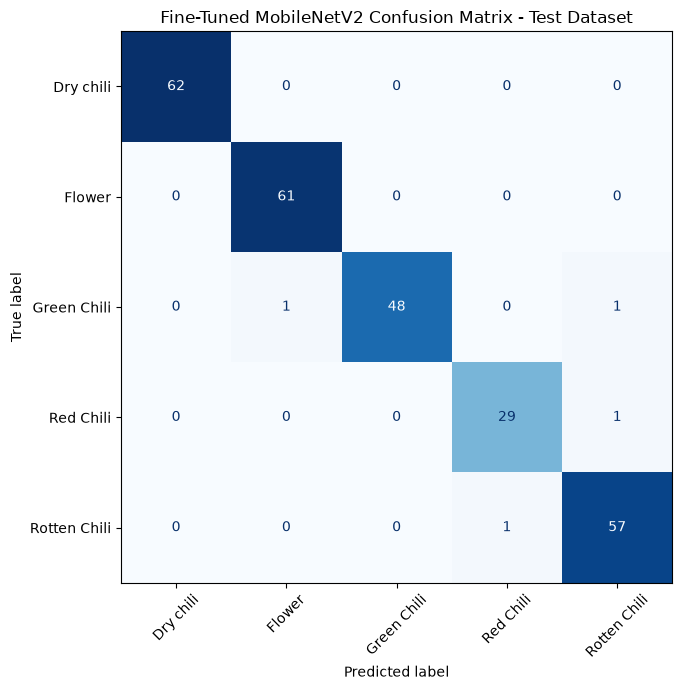

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fine_cm = confusion_matrix(
    y_true,
    fine_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=fine_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Fine-Tuned MobileNetV2 Confusion Matrix - Test Dataset"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
fine_model.save("final_chili_maturity_model.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_chili_image(image_path):
    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to array
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension
    img_batch = tf.expand_dims(img_array, axis=0)

    # Prediction
    predictions = fine_model.predict(
        img_batch,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    # Display image and result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("PREDICTION RESULT")
    print("----------------------------")
    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")

    return predicted_class, confidence

print("Single-image prediction function ready!")

Single-image prediction function ready!


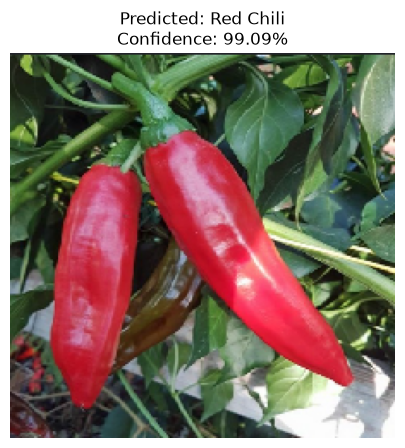

PREDICTION RESULT
----------------------------
Predicted Class : Red Chili
Confidence      : 99.09%


In [20]:
result = predict_chili_image(
    r"D:\Chili_Project\Test_Photos\test_photo1.png"
)

In [21]:
def predict_with_probabilities(image_path):
    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_batch = tf.expand_dims(img_array, axis=0)

    # Prediction
    predictions = fine_model.predict(img_batch, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    # Display original image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    # Convert all probabilities to percentages
    probabilities = predictions * 100

    # Probability bar chart
    plt.figure(figsize=(8, 5))
    plt.bar(class_names, probabilities)

    plt.xlabel("Chili Class")
    plt.ylabel("Confidence (%)")
    plt.title("Prediction Confidence for All Classes")
    plt.ylim(0, 100)
    plt.xticks(rotation=30)

    # Display percentage above each bar
    for i, value in enumerate(probabilities):
        plt.text(
            i,
            value + 1,
            f"{value:.2f}%",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

    print("\nPREDICTION PROBABILITIES")
    print("-" * 35)

    for name, probability in zip(class_names, probabilities):
        print(f"{name:15s}: {probability:.2f}%")

    print("\nFinal Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

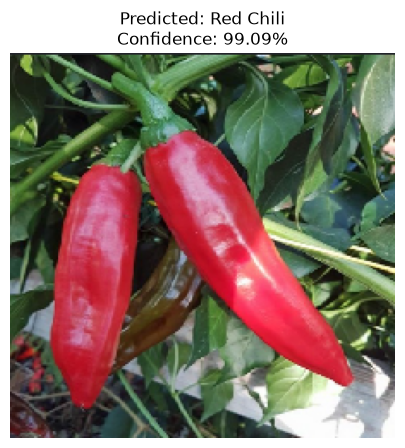

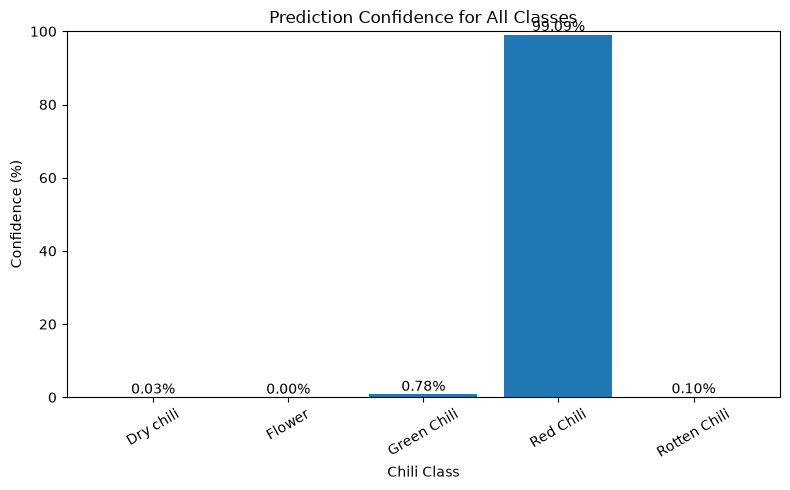


PREDICTION PROBABILITIES
-----------------------------------
Dry chili      : 0.03%
Flower         : 0.00%
Green Chili    : 0.78%
Red Chili      : 99.09%
Rotten Chili   : 0.10%

Final Prediction: Red Chili
Confidence: 99.09%


In [24]:
predict_with_probabilities(
    r"D:\Chili_Project\Test_Photos\test_photo1.png"
)

In [25]:
import os

print("Final model exists:",
      os.path.exists("final_chili_maturity_model.keras"))

print("Baseline model exists:",
      os.path.exists("best_mobilenetv2.keras"))

print("Fine-tuned model exists:",
      os.path.exists("best_mobilenetv2_finetuned.keras"))

Final model exists: True
Baseline model exists: True
Fine-tuned model exists: True


In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

model_path = r"D:\Chili_Project\final_chili_maturity_model.keras"

print("Final model exists:", os.path.exists(model_path))

final_model = tf.keras.models.load_model(model_path)

print("Final chili model loaded successfully!")

TensorFlow: 2.21.0
Final model exists: True
Final chili model loaded successfully!


In [2]:
farm_path = r"D:\Chili_Project\Test_Photos"

print("Farm folder exists:", os.path.exists(farm_path))

if os.path.exists(farm_path):
    print("\nFARM TEST IMAGE COUNT")
    print("-" * 35)

    total = 0

    for class_name in sorted(os.listdir(farm_path)):
        class_path = os.path.join(farm_path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".webp")
                )
            ]

            print(f"{class_name}: {len(images)} images")
            total += len(images)

    print("-" * 35)
    print("Total farm images:", total)

Farm folder exists: True

FARM TEST IMAGE COUNT
-----------------------------------
-----------------------------------
Total farm images: 0


In [3]:
farm_path = r"D:\Chili_Project\Test_Photos"

In [4]:
import os

test_photos_path = r"D:\Chili_Project\Test_Photos"

farm_classes = [
    "Flowers",
    "Green Chili",
    "Red Chili"
]

print("EXTERNAL FARM TEST IMAGE COUNT")
print("-" * 40)

total = 0

for class_name in farm_classes:
    class_path = os.path.join(test_photos_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ]

    print(f"{class_name}: {len(images)} images")
    total += len(images)

print("-" * 40)
print(f"Total external farm images: {total}")

EXTERNAL FARM TEST IMAGE COUNT
----------------------------------------
Flowers: 8 images
Green Chili: 6 images
Red Chili: 2 images
----------------------------------------
Total external farm images: 16


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

farm_ds = tf.keras.utils.image_dataset_from_directory(
    r"D:\Chili_Project\Test_Photos",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nFolder classes detected:", farm_ds.class_names)
print("Total batches:", tf.data.experimental.cardinality(farm_ds).numpy())

Found 16 files belonging to 3 classes.

Folder classes detected: ['Flowers', 'Green Chili', 'Red Chili']
Total batches: 1


In [6]:
# Original 5 classes used by the trained model
model_classes = [
    "Dry chili",
    "Flower",
    "Green Chili",
    "Red Chili",
    "Rotten Chili"
]

# Mapping external folder names to model class names
folder_to_model_class = {
    "Flowers": "Flower",
    "Green Chili": "Green Chili",
    "Red Chili": "Red Chili"
}

y_true_farm = []
y_pred_farm = []
confidence_farm = []
file_names_farm = []

# Get file paths in the same order as the dataset
farm_file_paths = farm_ds.file_paths

image_counter = 0

for images, labels in farm_ds:

    predictions = final_model.predict(images, verbose=0)

    predicted_indices = np.argmax(predictions, axis=1)
    confidences = np.max(predictions, axis=1) * 100

    for i in range(len(labels)):

        # Dataset true folder label
        folder_class = farm_ds.class_names[int(labels[i].numpy())]

        # Convert "Flowers" -> "Flower"
        true_class = folder_to_model_class[folder_class]

        predicted_class = model_classes[predicted_indices[i]]

        y_true_farm.append(true_class)
        y_pred_farm.append(predicted_class)
        confidence_farm.append(confidences[i])

        file_names_farm.append(
            os.path.basename(farm_file_paths[image_counter])
        )

        image_counter += 1


correct = sum(
    true == pred
    for true, pred in zip(y_true_farm, y_pred_farm)
)

farm_accuracy = correct / len(y_true_farm) * 100


print("EXTERNAL FARM TEST RESULTS")
print("=" * 65)

print(f"Total images : {len(y_true_farm)}")
print(f"Correct      : {correct}")
print(f"Incorrect    : {len(y_true_farm) - correct}")
print(f"Accuracy     : {farm_accuracy:.2f}%")

print("\nINDIVIDUAL PREDICTIONS")
print("=" * 65)

for file, true, pred, conf in zip(
    file_names_farm,
    y_true_farm,
    y_pred_farm,
    confidence_farm
):

    status = "CORRECT" if true == pred else "WRONG"

    print(
        f"{file}\n"
        f"Actual: {true} | "
        f"Predicted: {pred} | "
        f"Confidence: {conf:.2f}% | "
        f"{status}\n"
    )

EXTERNAL FARM TEST RESULTS
Total images : 16
Correct      : 9
Incorrect    : 7
Accuracy     : 56.25%

INDIVIDUAL PREDICTIONS
WhatsApp Image 2026-09-18 at 07.36.13 (2).jpeg
Actual: Flower | Predicted: Green Chili | Confidence: 53.72% | WRONG

WhatsApp Image 2026-09-18 at 07.36.13.jpeg
Actual: Flower | Predicted: Flower | Confidence: 74.84% | CORRECT

WhatsApp Image 2026-09-18 at 07.51.47 (1).jpeg
Actual: Flower | Predicted: Green Chili | Confidence: 71.84% | WRONG

WhatsApp Image 2026-09-18 at 07.51.47.jpeg
Actual: Flower | Predicted: Flower | Confidence: 47.36% | CORRECT

WhatsApp Image 2026-09-18 at 07.51.48 (1).jpeg
Actual: Flower | Predicted: Flower | Confidence: 99.98% | CORRECT

WhatsApp Image 2026-09-18 at 07.51.48.jpeg
Actual: Flower | Predicted: Green Chili | Confidence: 69.09% | WRONG

WhatsApp Image 2026-09-18 at 07.51.49 (1).jpeg
Actual: Flower | Predicted: Green Chili | Confidence: 55.33% | WRONG

WhatsApp Image 2026-09-18 at 07.51.49.jpeg
Actual: Flower | Predicted: Green 

Total misclassified farm images: 7


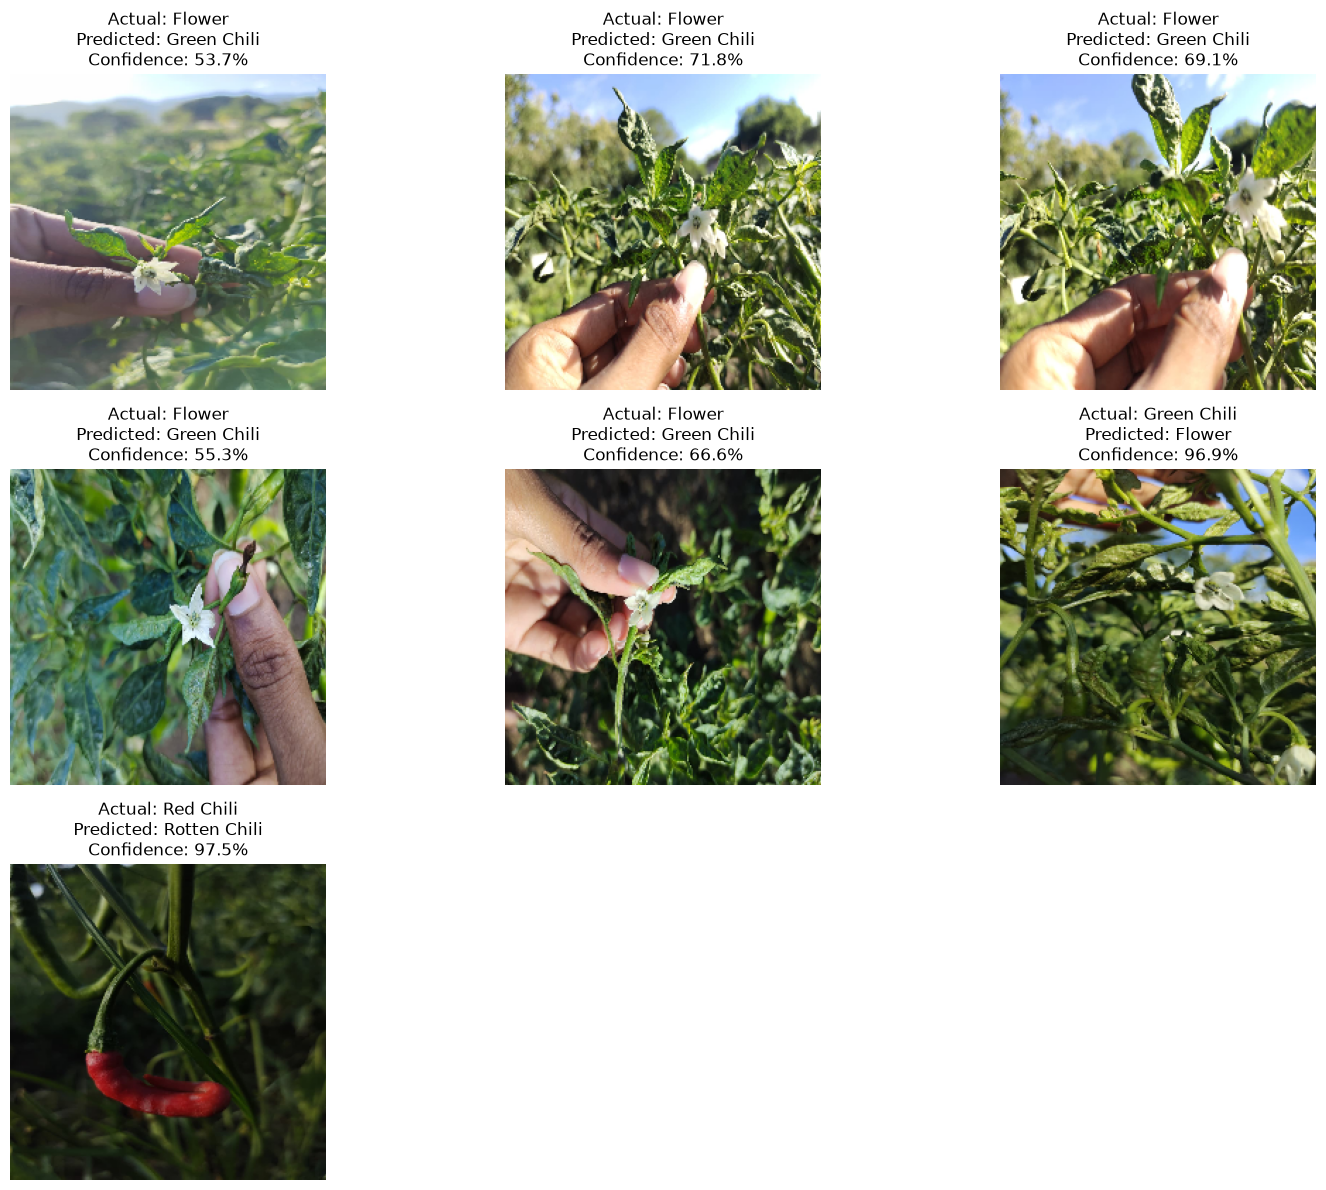

In [7]:
wrong_indices = [
    i for i, (true, pred) in enumerate(
        zip(y_true_farm, y_pred_farm)
    )
    if true != pred
]

print("Total misclassified farm images:", len(wrong_indices))

plt.figure(figsize=(15, 12))

for plot_num, idx in enumerate(wrong_indices):

    image_path = farm_file_paths[idx]

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    plt.subplot(3, 3, plot_num + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Actual: {y_true_farm[idx]}\n"
        f"Predicted: {y_pred_farm[idx]}\n"
        f"Confidence: {confidence_farm[idx]:.1f}%"
    )

plt.tight_layout()
plt.show()

In [9]:
#EfficientNetB0#

In [8]:
import os
import tensorflow as tf

dataset_path = r"D:\Chili_Project\dataset_split"

train_path = os.path.join(dataset_path, "train")
val_path   = os.path.join(dataset_path, "validation")
test_path  = os.path.join(dataset_path, "test")

print("Train exists:", os.path.exists(train_path))
print("Validation exists:", os.path.exists(val_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Validation exists: True
Test exists: True


In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

Found 1198 files belonging to 5 classes.
Found 255 files belonging to 5 classes.
Found 261 files belonging to 5 classes.

Classes: ['Dry chili', 'Flower', 'Green Chili', 'Red Chili', 'Rotten Chili']
Number of classes: 5


In [11]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Data augmentation
efficient_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="efficientnet_augmentation")

# Pre-trained EfficientNetB0
efficient_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model initially
efficient_base.trainable = False

# Build classification model
inputs = layers.Input(shape=(224, 224, 3))

x = efficient_augmentation(inputs)

# Important:
# EfficientNetB0 in current Keras already includes input rescaling,
# so we do NOT add MobileNetV2 preprocessing here.
x = efficient_base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

efficient_model = models.Model(
    inputs,
    outputs,
    name="Chili_Maturity_EfficientNetB0"
)

efficient_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


Model: "Chili_Maturity_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnet_augmentation            │ (None, 224, 224, 3)         │               0 │
│ (Sequential)                         │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully!")

EfficientNetB0 compiled successfully!


In [13]:
efficient_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("EfficientNetB0 callbacks ready!")

EfficientNetB0 callbacks ready!


In [14]:
EFFICIENT_EPOCHS = 10

efficient_history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EFFICIENT_EPOCHS,
    callbacks=efficient_callbacks
)

D:\Chili_Project\chili_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7546 - loss: 0.7228
Epoch 1: val_accuracy improved from None to 0.90588, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.7546 - loss: 0.7228 - val_accuracy: 0.9059 - val_loss: 0.3242 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9549 - loss: 0.2389
Epoch 2: val_accuracy improved from 0.90588 to 0.95686, saving model to best_efficientnetb0.keras

Epoch 2: finished saving model to best_efficientnetb0.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9549 - loss: 0.2389 - val_accuracy: 0.9569 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9624 - loss: 0.1636
Epoch 3: val_accuracy improved from 0.95686 to 0.96863, saving model to best_efficientnetb0.keras

Epoch 3: finished saving model to best_efficientnetb0.ker

In [15]:
# Unfreeze EfficientNetB0 base
efficient_base.trainable = True

# Keep most layers frozen
# Fine-tune only the last 30 layers
for layer in efficient_base.layers[:-30]:
    layer.trainable = False

print("Total EfficientNetB0 layers:", len(efficient_base.layers))
print(
    "Trainable base layers:",
    sum(1 for layer in efficient_base.layers if layer.trainable)
)

Total EfficientNetB0 layers: 238
Trainable base layers: 30


In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

efficient_path = r"D:\Chili_Project\best_efficientnetb0.keras"

print("Model exists:", os.path.exists(efficient_path))

efficient_model = tf.keras.models.load_model(efficient_path)

print("EfficientNetB0 baseline loaded successfully!")

Model exists: True
EfficientNetB0 baseline loaded successfully!


In [2]:
# Get EfficientNetB0 base model
efficient_base = efficient_model.get_layer("efficientnetb0")

# Unfreeze the base model
efficient_base.trainable = True

# Freeze all except the last 30 layers
for layer in efficient_base.layers[:-30]:
    layer.trainable = False

print("Total EfficientNetB0 layers:", len(efficient_base.layers))
print(
    "Trainable base layers:",
    sum(1 for layer in efficient_base.layers if layer.trainable)
)

Total EfficientNetB0 layers: 238
Trainable base layers: 30


In [3]:
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 fine-tuning model compiled successfully!")

EfficientNetB0 fine-tuning model compiled successfully!


In [4]:
efficient_fine_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_efficientnetb0_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuning callbacks ready!")

Fine-tuning callbacks ready!


In [5]:
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

dataset_path = r"D:\Chili_Project\dataset_split"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "validation")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Improve loading performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print("Train and validation datasets ready!")

Found 1198 files belonging to 5 classes.
Found 255 files belonging to 5 classes.
Train and validation datasets ready!


In [6]:
FINE_TUNE_EPOCHS = 10

efficient_fine_history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=efficient_fine_callbacks
)

Epoch 1/10


D:\Chili_Project\chili_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8998 - loss: 0.3700
Epoch 1: val_accuracy improved from None to 0.98039, saving model to best_efficientnetb0_finetuned.keras

Epoch 1: finished saving model to best_efficientnetb0_finetuned.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.8998 - loss: 0.3700 - val_accuracy: 0.9804 - val_loss: 0.0612 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9366 - loss: 0.2881
Epoch 2: val_accuracy did not improve from 0.98039
38/38 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9366 - loss: 0.2881 - val_accuracy: 0.9804 - val_loss: 0.0678 - learning_rate: 1.0000e-05
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9491 - loss: 0.2446
Epoch 3: val_accuracy did not improve from 0.98039

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.9491 - loss: 0.2446 - val_accuracy: 0.9765 - val_loss: 0.0745 - 

In [7]:
test_path = r"D:\Chili_Project\dataset_split\test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print("Test dataset ready!")

Found 261 files belonging to 5 classes.
Test dataset ready!


In [8]:
test_loss_eff, test_acc_eff = efficient_model.evaluate(
    test_ds
)

print("\nEFFICIENTNETB0 FINE-TUNED TEST RESULTS")
print("-" * 45)
print(f"Test Accuracy: {test_acc_eff * 100:.2f}%")
print(f"Test Loss: {test_loss_eff:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9923 - loss: 0.0359

EFFICIENTNETB0 FINE-TUNED TEST RESULTS
---------------------------------------------
Test Accuracy: 99.23%
Test Loss: 0.0359


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_true_eff = []
y_pred_eff = []

for images, labels in test_ds:
    predictions = efficient_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true_eff.extend(labels.numpy())
    y_pred_eff.extend(predicted_classes)

y_true_eff = np.array(y_true_eff)
y_pred_eff = np.array(y_pred_eff)

class_names = test_ds.class_names

print("\nEFFICIENTNETB0 CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true_eff,
        y_pred_eff,
        target_names=class_names,
        digits=4
    )
)


EFFICIENTNETB0 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Dry chili     1.0000    1.0000    1.0000        62
      Flower     1.0000    0.9672    0.9833        61
 Green Chili     0.9615    1.0000    0.9804        50
   Red Chili     1.0000    1.0000    1.0000        30
Rotten Chili     1.0000    1.0000    1.0000        58

    accuracy                         0.9923       261
   macro avg     0.9923    0.9934    0.9927       261
weighted avg     0.9926    0.9923    0.9923       261



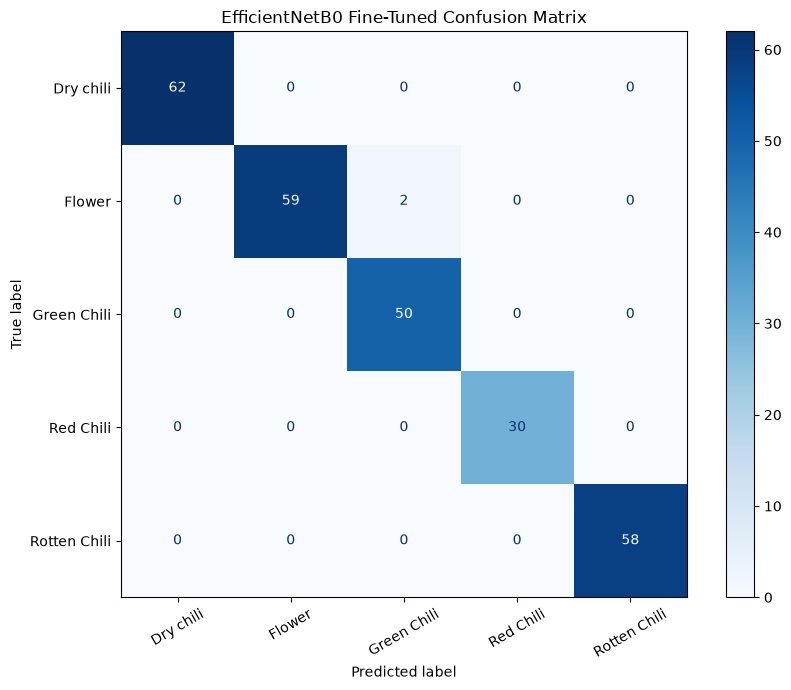

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_eff,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("EfficientNetB0 Fine-Tuned Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
final_eff_path = r"D:\Chili_Project\final_efficientnetb0_chili_model.keras"

efficient_model.save(final_eff_path)

print("Final EfficientNetB0 model saved!")
print("Path:", final_eff_path)

Final EfficientNetB0 model saved!
Path: D:\Chili_Project\final_efficientnetb0_chili_model.keras


In [12]:
import os

print(
    "Final model exists:",
    os.path.exists(
        r"D:\Chili_Project\final_efficientnetb0_chili_model.keras"
    )
)

Final model exists: True
